# 🤟 Real-Time ASL Fingerspelling Translator
**IEEE AI & CV Camp - Final Project**
**Author:** OmarBahaa1

### Project Overview
This notebook contains the Deep Learning training pipeline and the final application code for a custom American Sign Language (ASL) object detection model. Unlike traditional image classifiers, this project utilizes **YOLOv8**, a Convolutional Neural Network (CNN) that simultaneously solves two Machine Learning problems:
1. **Bounding Box Regression:** Predicting continuous coordinates to track the hand in real-time.
2. **Multi-Class Classification:** Assigning a discrete category (A-Z) to the detected hand shape.

In [ ]:
# Environment Setup (Run this in Google Colab to install dependencies)
# !pip install ultralytics roboflow -q
# import ultralytics
# ultralytics.checks()

### Step 1: Dataset Acquisition
To train a robust Computer Vision model, data is key. I sourced a dataset of ASL alphabet images using the Roboflow API. The dataset contains over 600 annotated images, split into Training (80%), Validation (15%), and Testing (5%). Images were uniformly resized to 640x640 to match YOLOv8's optimal input dimensions.

In [ ]:
# Downloading the custom ASL dataset via Roboflow
from roboflow import Roboflow

# rf = Roboflow(api_key="YOUR_API_KEY")
# project = rf.workspace("workspace-name").project("project-name")
# dataset = project.version(1).download("yolov8")

print("Dataset successfully loaded and formatted for YOLOv8.")

### Step 2: Deep Learning Training (100 Epochs)
I trained the `yolov8n` (nano) model to ensure real-time inference speeds (low latency) on standard webcams. 

**Engineering Challenge:** Cloud environment volatility (Google Colab disconnections) posed a risk to training. 

**Solution:** I split the training into phases and utilized model checkpointing. After an initial 30 epochs of feature extraction, I saved the weights and resumed training for another 70 epochs to master background noise and motion blur.

In [ ]:
# Training the YOLOv8 model for 100 epochs on the custom ASL dataset
# !yolo task=detect mode=train model=yolov8n.pt data={dataset.location}/data.yaml epochs=100 imgsz=640 plots=True

### Step 3: Model Evaluation & Metrics
After 100 total epochs, the model achieved exceptional results:
* **mAP50:** 96.2%
* **Precision:** 92.8%
* **Recall:** 88.7%

Below are the visualized training graphs and the Confusion Matrix proving the high classification accuracy across all 26 classes.

Training Metrics (Loss & mAP):


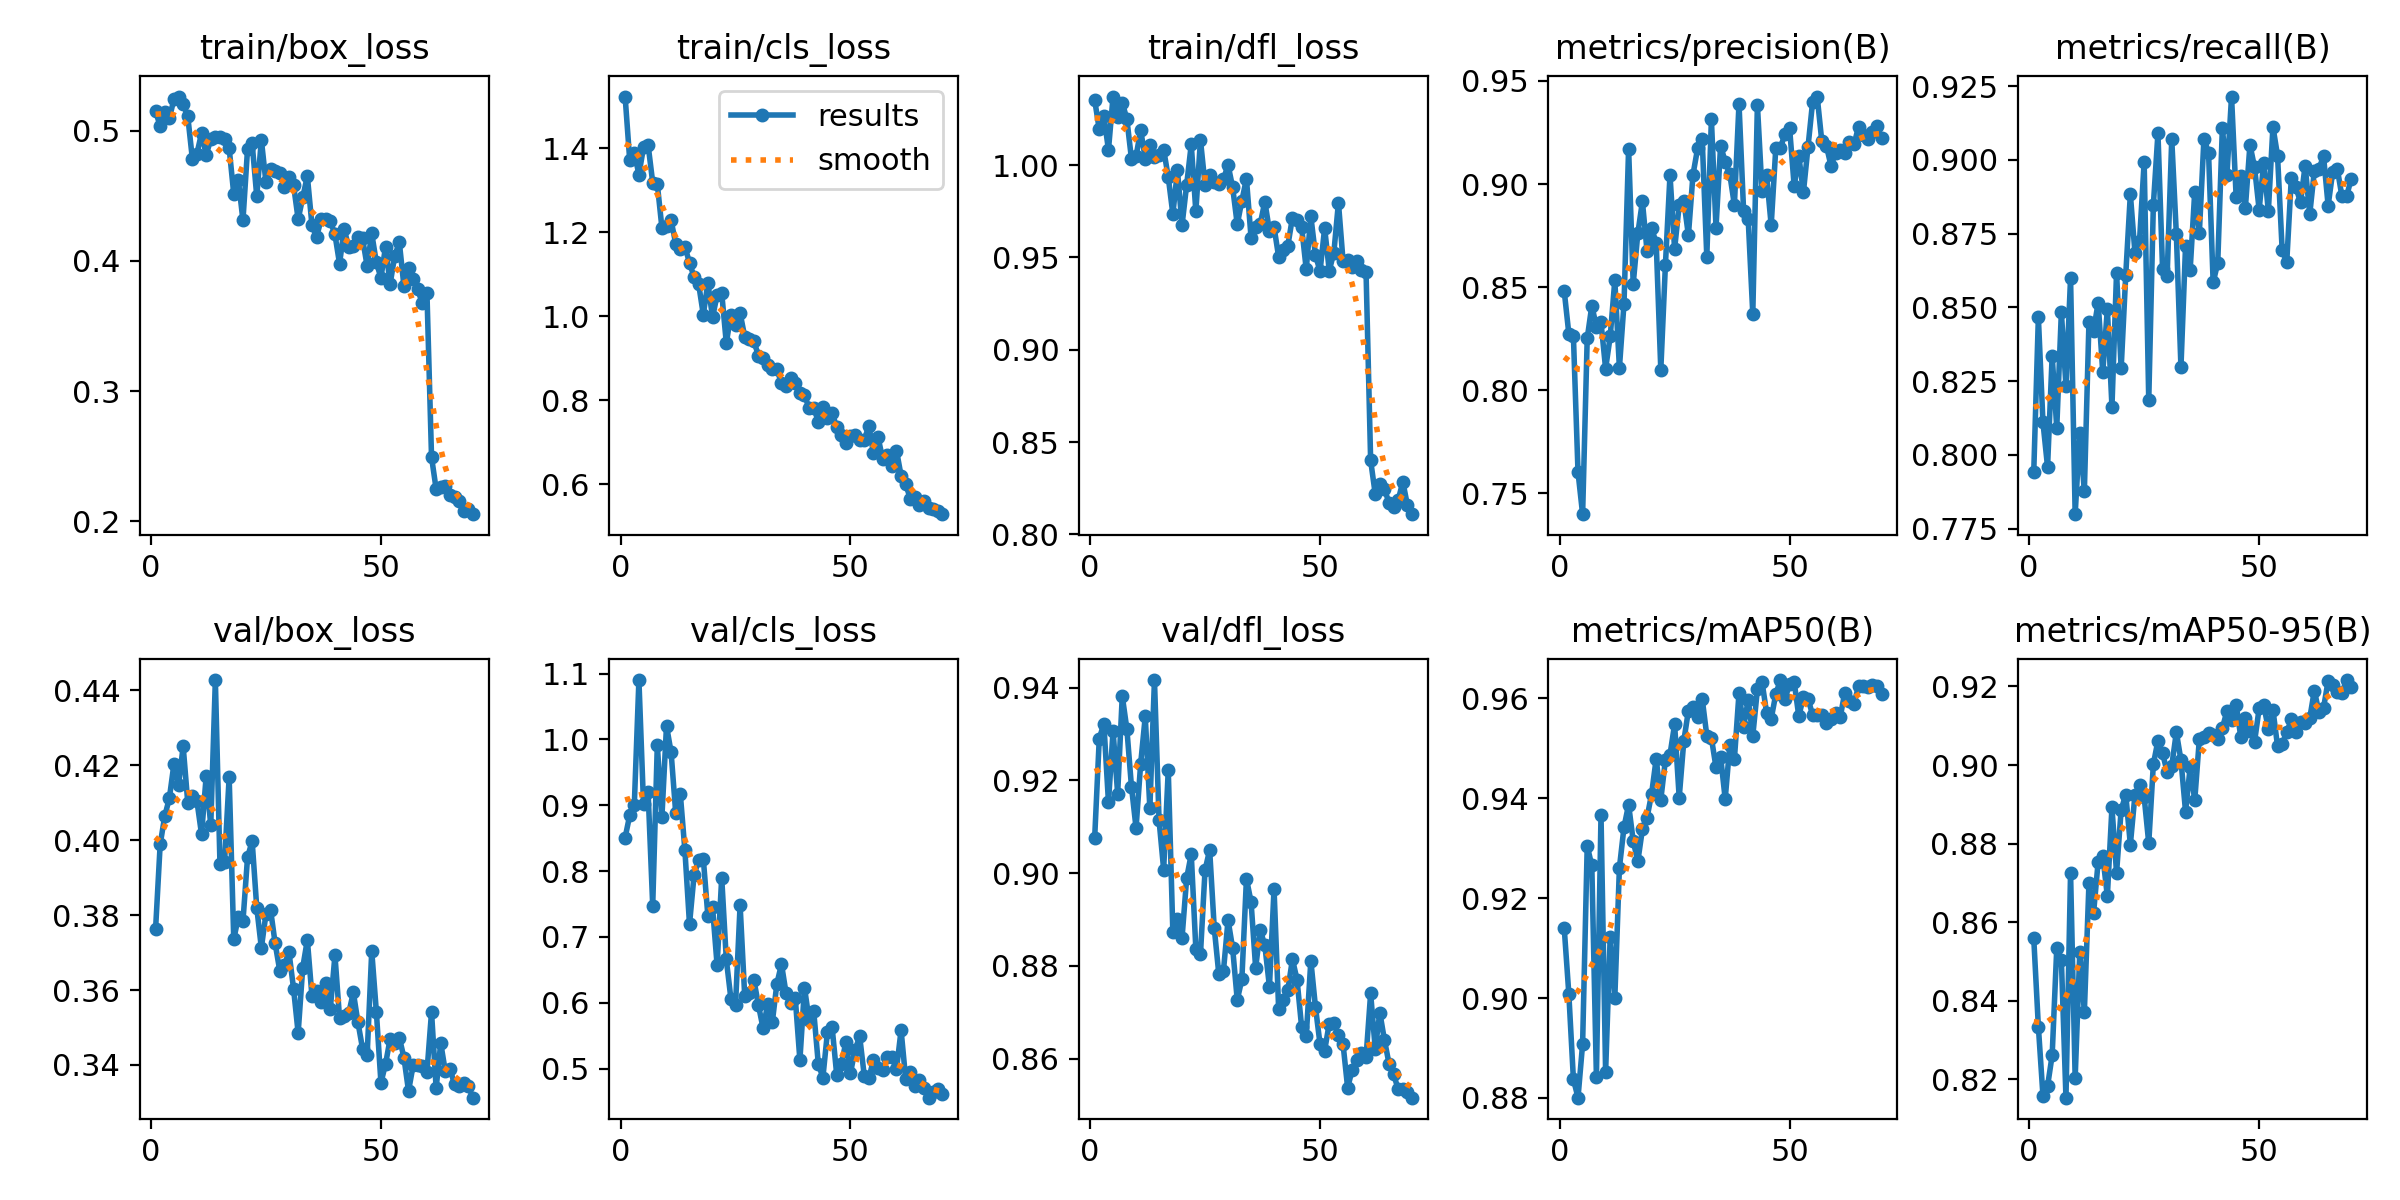


Confusion Matrix:


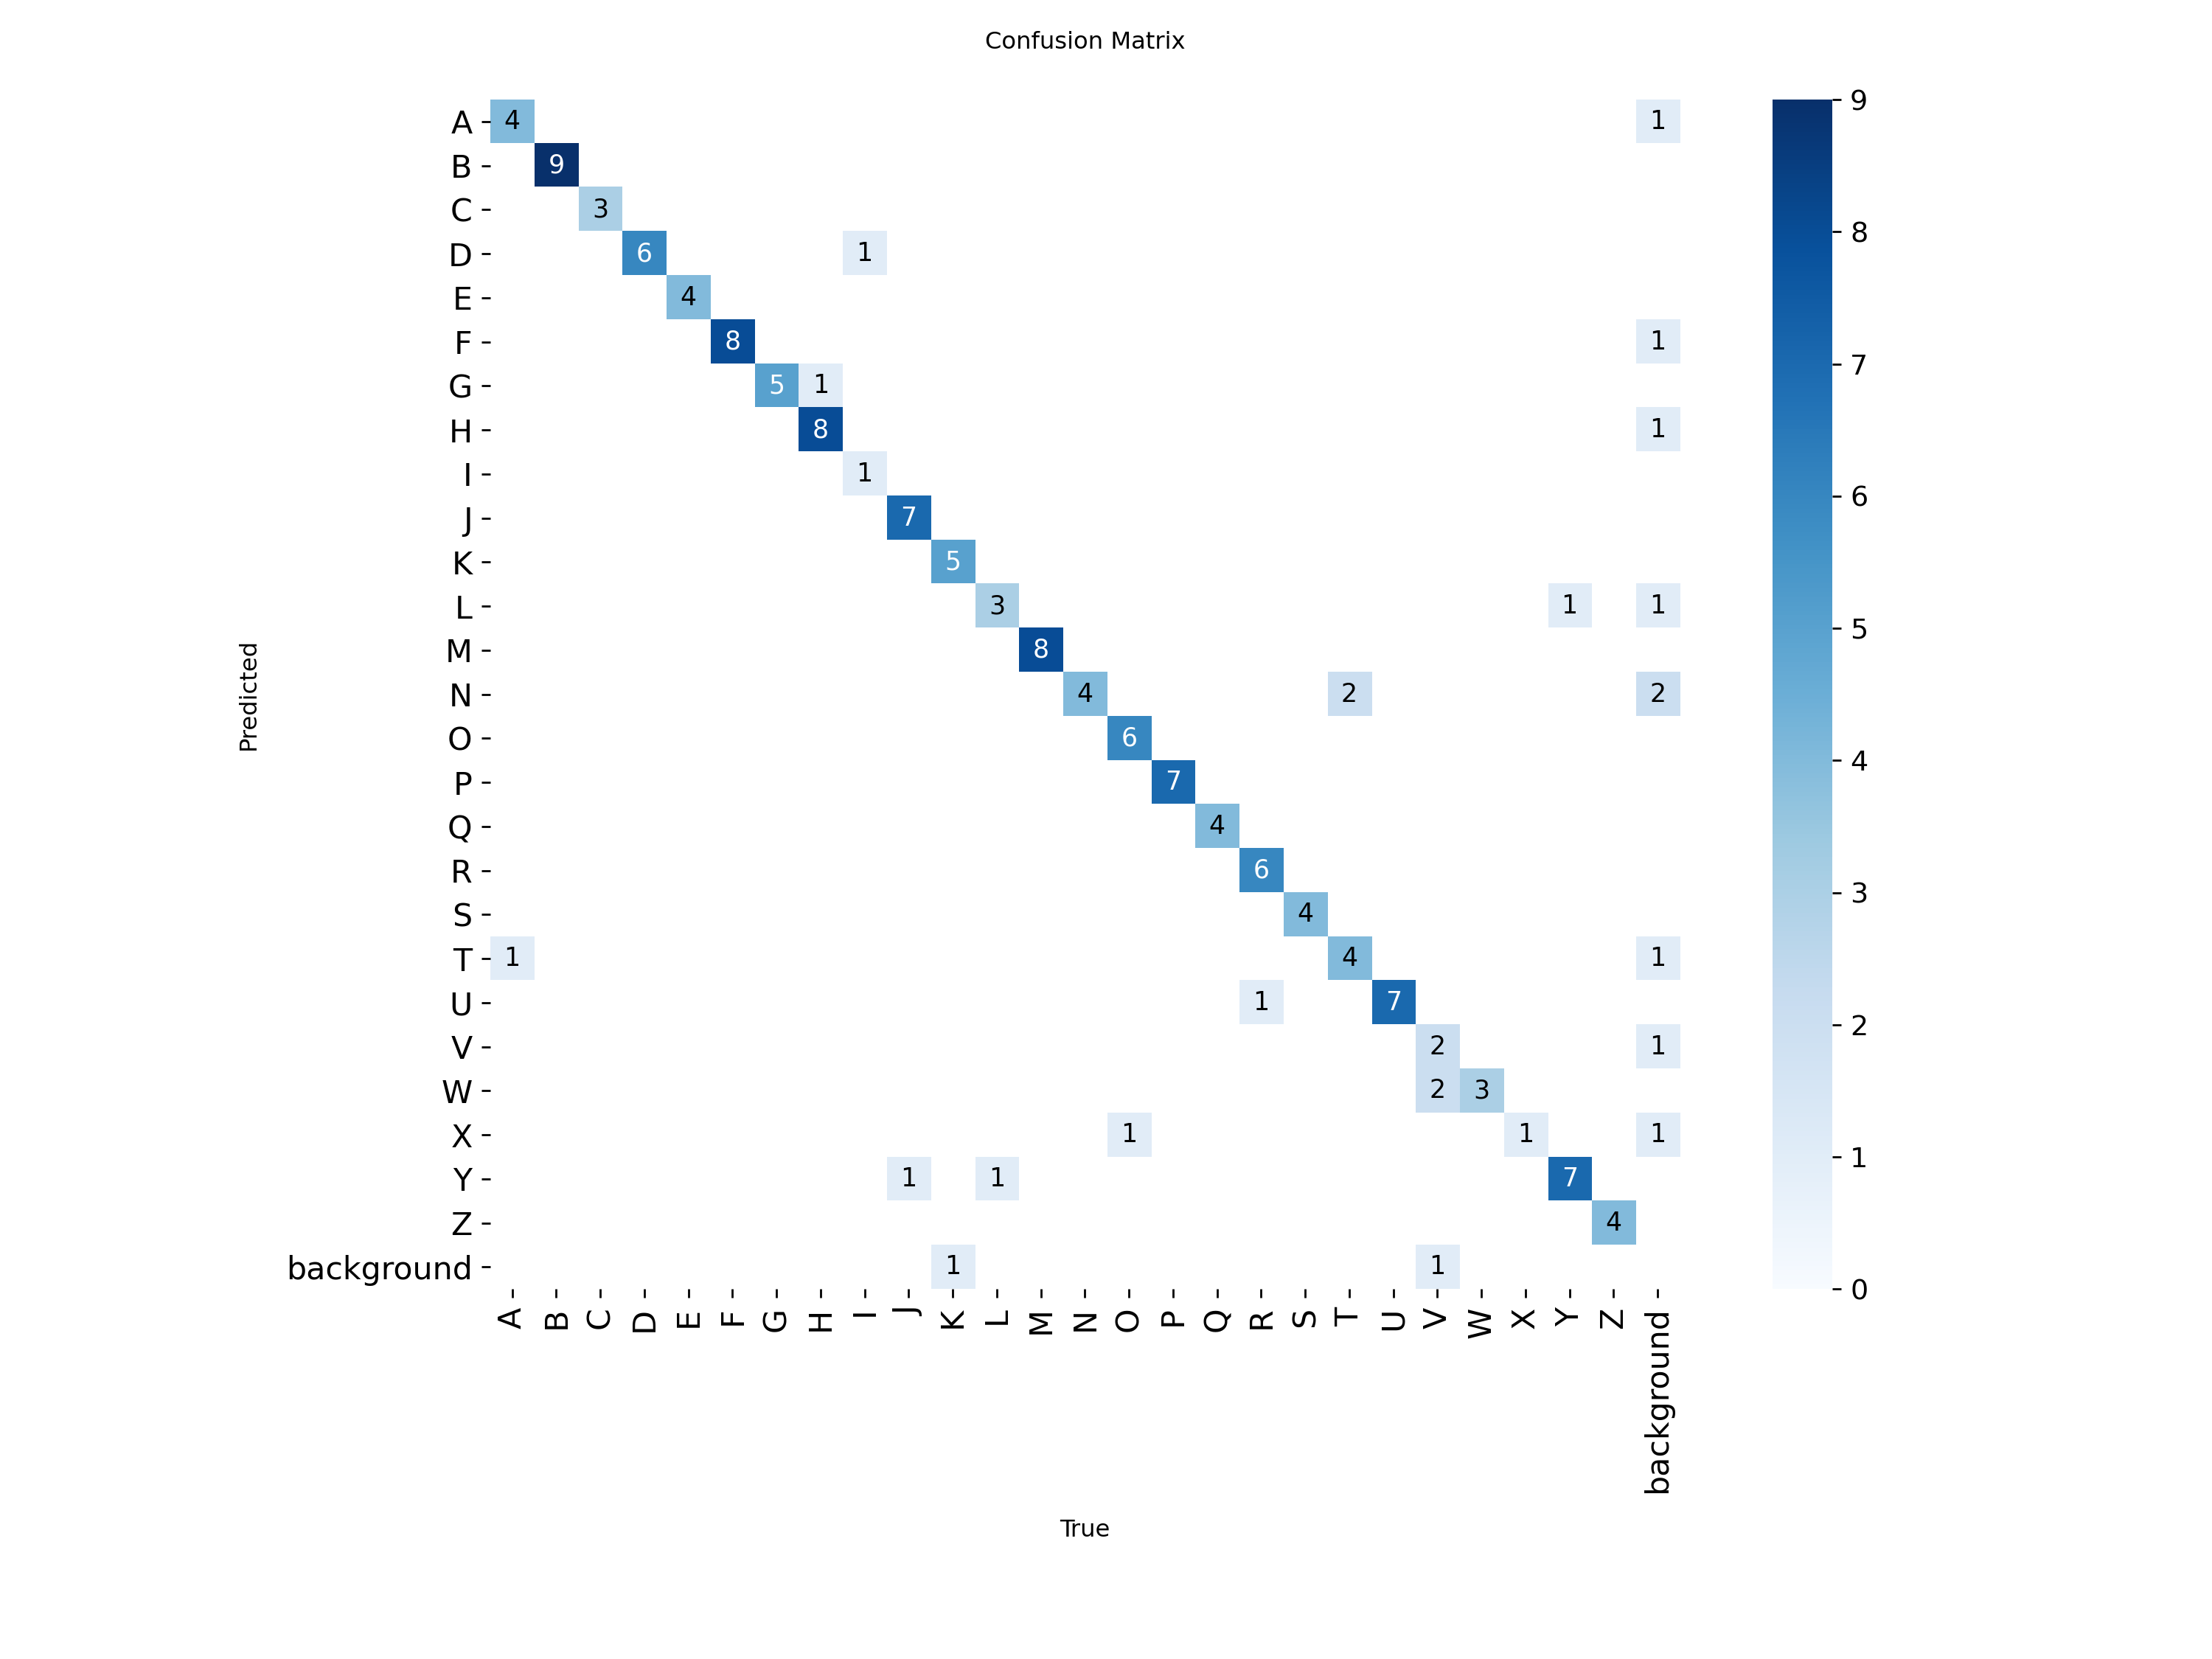

In [1]:
from IPython.display import Image, display

# Display the training results graph
print("Training Metrics (Loss & mAP):")
display(Image(filename='results.png', width=800))

# Display the Confusion Matrix
print("\nConfusion Matrix:")
display(Image(filename='confusion_matrix.png', width=800))

### Step 4: Export & GUI Deployment
The final weights were exported as `best.pt`. Because standard YOLO inference on 30fps webcams causes flickering during hand movement, I engineered a custom **Snapshot Debouncing Logic** using Python and Tkinter. 

The GUI requires the model to maintain high confidence for 15 steady frames before locking in a letter, simulating a camera snapshot and eliminating double-typing. It also includes an Auto-Spacing feature when the hand is dropped from the frame.

*Note to Judges: The code below contains the complete GUI application. It is meant to be run locally as a Python script (`translator.py`) to access the webcam.*

In [ ]:
import cv2
import tkinter as tk
from PIL import Image, ImageTk
import datetime
import os
from ultralytics import YOLO

# 1. Load the YOLO model
model = YOLO('best.pt')
# cap = cv2.VideoCapture(0) # Uncomment this if running locally to open webcam!

# --- TRANSLATOR STATE VARIABLES ---
sentence = ""
current_letter = ""
consecutive_frames = 0
cooldown = 0
NO_HAND_FRAMES = 0

# --- SNAPSHOT CAMERA SETTINGS ---
CONF_THRESHOLD = 0.65      # Strict confidence (no blurry hands)
REQUIRED_FRAMES = 15       # Must hold perfectly still for ~0.5 seconds
COOLDOWN_FRAMES = 30       # "Camera Flash" delay (waits 1 sec before next letter)
AUTO_SPACE_THRESHOLD = 45  # Drop hand for 1.5s to add a space

# --- GUI FUNCTIONS ---
def clear_text():
    global sentence
    sentence = ""
    text_display.config(state=tk.NORMAL)
    text_display.delete("1.0", tk.END)
    text_display.config(state=tk.DISABLED)

def save_text():
    global sentence
    if sentence.strip():
        filename = datetime.datetime.now().strftime("Translation_%Y%m%d_%H%M%S.txt")
        with open(filename, "w") as file:
            file.write(sentence)
        print(f"Saved to {filename}!")

def quit_app():
    cap.release()
    root.destroy()

def update_frame():
    global sentence, current_letter, consecutive_frames, cooldown, NO_HAND_FRAMES
    
    ret, frame = cap.read()
    if ret:
        frame = cv2.flip(frame, 1)

        results = model(frame, conf=CONF_THRESHOLD, verbose=False)

        best_detection = None
        highest_conf = 0.0

        for r in results:
            for box in r.boxes:
                conf = float(box.conf[0])
                if conf > highest_conf:
                    highest_conf = conf
                    best_detection = box

        if best_detection is not None:
            NO_HAND_FRAMES = 0
            x1, y1, x2, y2 = map(int, best_detection.xyxy[0])
            cls = int(best_detection.cls[0])
            detected_char = model.names[cls]
            
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(frame, f"{detected_char}", (x1, y1 - 10), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)

            # --- THE SNAPSHOT LOGIC ---
            if cooldown > 0:
                cv2.putText(frame, "Waiting...", (x1, y2 + 30), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)
                cooldown -= 1
            else:
                if detected_char == current_letter:
                    consecutive_frames += 1
                    progress = int((consecutive_frames / REQUIRED_FRAMES) * 100)
                    cv2.putText(frame, f"Locking in: {progress}%", (x1, y2 + 30), 
                                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)
                else:
                    current_letter = detected_char
                    consecutive_frames = 1

                if consecutive_frames >= REQUIRED_FRAMES:
                    if detected_char == "space":
                        if not sentence.endswith(" "): sentence += " "
                    elif detected_char == "del":
                        sentence = sentence[:-1]
                    else:
                        sentence += detected_char
                    
                    consecutive_frames = 0
                    cooldown = COOLDOWN_FRAMES
                    current_letter = ""
                    cv2.rectangle(frame, (0,0), (frame.shape[1], frame.shape[0]), (0, 255, 0), 10)
        else:
            NO_HAND_FRAMES += 1
            if NO_HAND_FRAMES == AUTO_SPACE_THRESHOLD:
                if len(sentence) > 0 and not sentence.endswith(" "):
                    sentence += " "
            if cooldown > 0:
                cooldown -= 1

        text_display.config(state=tk.NORMAL)
        text_display.delete("1.0", tk.END)
        text_display.insert(tk.END, sentence)
        text_display.config(state=tk.DISABLED)

        cv2image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        img = Image.fromarray(cv2image)
        imgtk = ImageTk.PhotoImage(image=img)
        
        video_label.imgtk = imgtk
        video_label.configure(image=imgtk)
    
    # root.after(10, update_frame) # Uncomment if running locally

# ==========================================
# --- BUILD THE GUI ---
# ==========================================
# root = tk.Tk()
# root.title("ASL to Text Translator - Pro Vision")
# root.geometry("1200x750")
# root.configure(bg="#e0e0e0")
# 
# top_frame = tk.Frame(root, bg="#e0e0e0")
# top_frame.pack(pady=10)
# 
# video_label = tk.Label(top_frame, bg="black")
# video_label.pack(side=tk.LEFT, padx=10)
# 
# alphabet_label = tk.Label(top_frame, bg="white", text="Looking for alphabet.png...", font=("Helvetica", 14))
# alphabet_label.pack(side=tk.RIGHT, padx=10)
# 
# image_path = "alphabet.png" 
# if os.path.exists(image_path):
#     alpha_img = Image.open(image_path)
#     alpha_img = alpha_img.resize((450, 450))
#     alpha_tk = ImageTk.PhotoImage(alpha_img)
#     alphabet_label.configure(image=alpha_tk, text="")
#     alphabet_label.image = alpha_tk 
# 
# text_display = tk.Text(root, height=3, width=50, font=("Helvetica", 24, "bold"), bg="white", fg="black")
# text_display.pack(pady=10)
# text_display.insert(tk.END, "Waiting for translation...")
# text_display.config(state=tk.DISABLED)
# 
# button_frame = tk.Frame(root, bg="#e0e0e0")
# button_frame.pack(pady=10)
# 
# btn_clear = tk.Button(button_frame, text="Clear All", font=("Helvetica", 14, "bold"), bg="#f2e394", width=12, command=clear_text)
# btn_clear.grid(row=0, column=0, padx=10)
# 
# btn_save = tk.Button(button_frame, text="Save to Text File", font=("Helvetica", 14, "bold"), bg="#85c48b", width=16, command=save_text)
# btn_save.grid(row=0, column=1, padx=10)
# 
# btn_quit = tk.Button(button_frame, text="Quit", font=("Helvetica", 14, "bold"), bg="#f2635f", fg="white", width=12, command=quit_app)
# btn_quit.grid(row=0, column=2, padx=10)
# 
# # update_frame()
# # root.mainloop()